# Data Analysis Interview Challenge: 
## Use Predictive Modelling to Profile Active Users for a Rideshare Service

**Assignment:** Ultimate is interested in predicting rider retention. To help explore this question, we have provided a sample dataset of a cohort of users who signed up for an Ultimate account in January 2014. The data was pulled several months later; we consider a user retained if they were “active” (i.e. took a trip) in the preceding 30 days. 

We would like you to use this data set to help understand what factors are the best predictors for retention, and offer suggestions to operationalize those insights to help Ultimate.

Additional details on the assignment can be found in `ultimate_data_science_challenge.pdf`.


**Devon's Response Begins:** Ultimate is interested in predicting rider retention. To help explore this question, we have provided a sample dataset of a cohort of users who signed up for an Ultimate account in January 2014. The data was pulled several months later; we consider a user retained if they were “active” (i.e. took a trip) in the preceding 30 days. We would like you to use this data set to help understand what factors are the best predictors for retention, and offer suggestions to operationalize those insights to help Ultimate.

The data is in the attached file ultimate_data_challenge.json. 
1. Perform any cleaning, exploratory analysis, and/or visualizations to use the provided data for this analysis. What fraction of the observed users were retained?  
2. Build a predictive model to help Ultimate determine whether or not a user will be active in their 6th month on the system. Discuss why you chose your approach, what alternatives you considered, and any concerns you have. How valid is your model? Include any key indicators of model performance.  
3. Briefly discuss how Ultimate might leverage the insights gained from the model to improve its long term rider retention.

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from catboost import CatBoostClassifier
import shap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV
from xgboost import XGBClassifier

### Data Cleaning and EDA

In [180]:
with open('ultimate_data_challenge.json', 'r') as file:
    data = json.load(file)

In [181]:
trips = pd.DataFrame(data)
trips.head(10)

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9
5,Winterfell,2,2014-01-09,3.5,1.00,2014-06-06,iPhone,0.0,True,100.0,10.56,5.0
6,Astapor,1,2014-01-24,NaN,1.00,2014-01-25,Android,0.0,False,100.0,3.95,4.0
7,Winterfell,2,2014-01-28,5.0,1.00,2014-01-29,iPhone,0.0,False,100.0,2.04,5.0
8,Winterfell,2,2014-01-21,4.5,1.00,2014-02-01,Android,0.0,False,100.0,4.36,5.0
9,Winterfell,1,2014-01-03,NaN,1.00,2014-01-05,Android,0.0,False,0.0,2.37,5.0


In [182]:
trips.isna().sum()

city                         0
trips_in_first_30_days       0
signup_date                  0
avg_rating_of_driver      8122
avg_surge                    0
last_trip_date               0
phone                      396
surge_pct                    0
ultimate_black_user          0
weekday_pct                  0
avg_dist                     0
avg_rating_by_driver       201
dtype: int64

We'll leave the Nas for a moment so we can plot the histograms, then fill them afterwards.

In [183]:
trips.dtypes

city                          str
trips_in_first_30_days      int64
signup_date                   str
avg_rating_of_driver      float64
avg_surge                 float64
last_trip_date                str
phone                         str
surge_pct                 float64
ultimate_black_user          bool
weekday_pct               float64
avg_dist                  float64
avg_rating_by_driver      float64
dtype: object

In [184]:
trips['signup_date'] = pd.to_datetime(trips['signup_date'])
trips['last_trip_date'] = pd.to_datetime(trips['last_trip_date'])
trips.dtypes

city                                 str
trips_in_first_30_days             int64
signup_date               datetime64[us]
avg_rating_of_driver             float64
avg_surge                        float64
last_trip_date            datetime64[us]
phone                                str
surge_pct                        float64
ultimate_black_user                 bool
weekday_pct                      float64
avg_dist                         float64
avg_rating_by_driver             float64
dtype: object

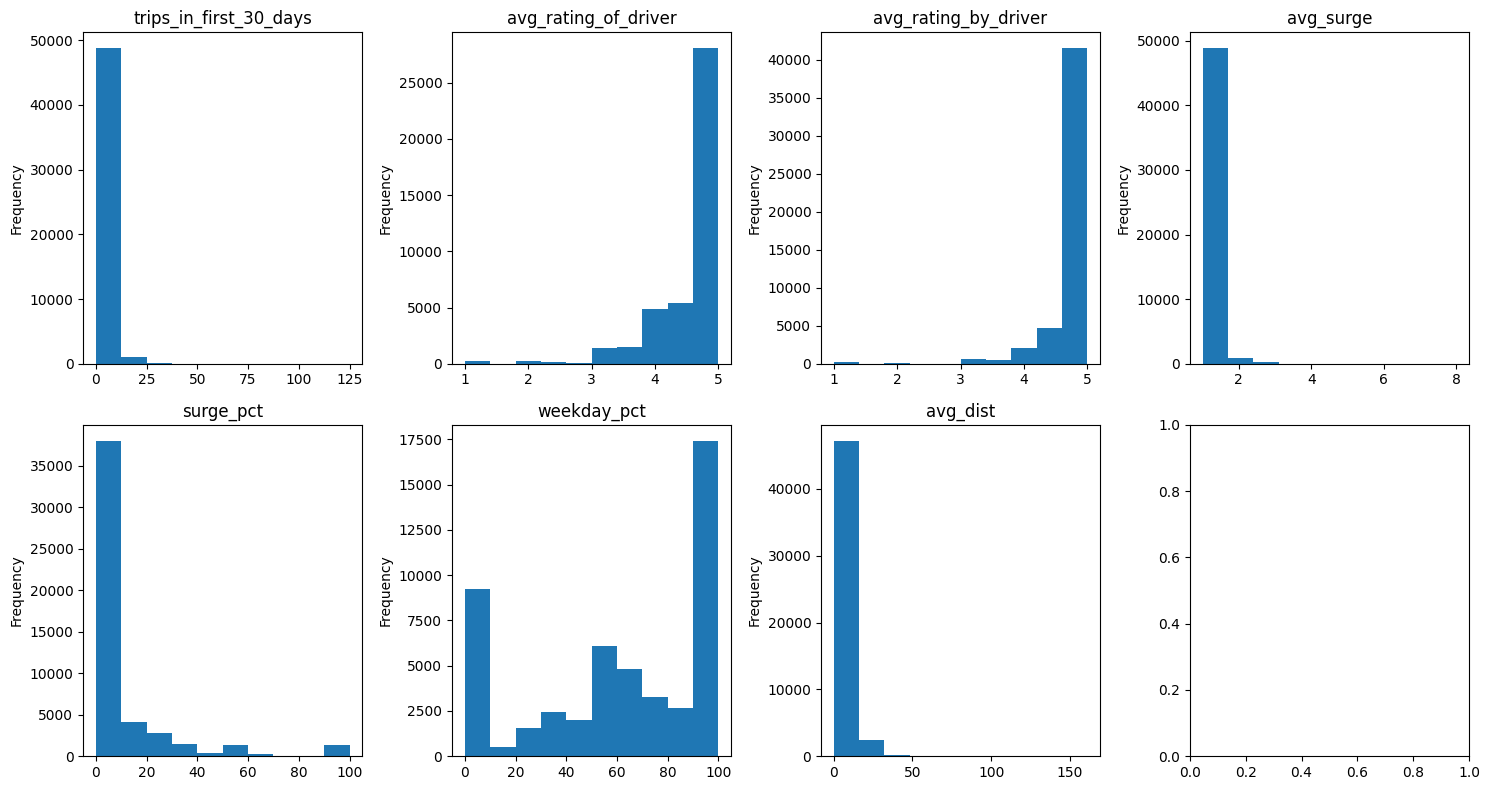

In [185]:
cols = ['trips_in_first_30_days', 'avg_rating_of_driver', 'avg_rating_by_driver', 'avg_surge', 'surge_pct', 'weekday_pct', 'avg_dist']

fig, ax = plt.subplots(2, 4, figsize = (15,8))
ax = ax.flatten()
for i, col in enumerate(cols):
    trips[col].plot(kind='hist', ax=ax[i], title=col)

plt.tight_layout()
plt.show()

Interpretation:
1) Both ratings by and of drivers are all within 0-5, which is as expected.
2) Average surge, percent surge and average distance are all reasonable.  Most importantly, surge_pct is under 100.
3) Average distance and average surge have one or more outliers, but this isn't surprising and doesn't justify removing data.
4) The only concerning data here are the trips int 30 days. An outlier at 125 is over 4 trips per day, sustained for 30 days.  That doesn't seem possible, so let's take a closer look.

In [186]:
too_many = trips[trips['trips_in_first_30_days'] >= 50]
too_many

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
99,Astapor,73,2014-01-27,4.9,1.00,2014-03-05,Android,0.0,True,89.7,2.86,4.9
3030,Winterfell,71,2014-01-06,4.9,1.06,2014-06-28,iPhone,2.9,True,85.9,2.32,4.8
10863,Winterfell,53,2014-01-05,4.1,1.02,2014-06-30,iPhone,3.4,True,70.5,2.58,4.7
17942,Winterfell,55,2014-01-07,4.6,1.03,2014-06-25,iPhone,5.3,True,68.0,3.27,4.7
18514,King's Landing,125,2014-01-02,5.0,1.12,2014-06-30,iPhone,14.4,True,72.0,2.02,4.8
25520,Winterfell,50,2014-01-17,4.8,1.00,2014-05-03,iPhone,0.0,False,70.5,6.20,4.8
29043,King's Landing,55,2014-01-22,4.8,1.03,2014-06-30,iPhone,4.8,True,66.5,3.39,4.6
29070,Astapor,63,2014-01-10,4.0,1.07,2014-06-29,iPhone,7.3,True,83.3,1.45,4.6
31047,Winterfell,54,2014-01-25,4.9,1.10,2014-06-29,iPhone,9.1,True,83.0,2.19,4.5
33488,King's Landing,54,2014-01-01,4.9,1.05,2014-07-01,iPhone,6.8,True,70.7,2.91,4.9


It looks like one outler at 125, and 50-70 trips in the first 30 days is normal enough to leave them alone.  I'll remove the one the one row with 125 trips as it is likely an error.

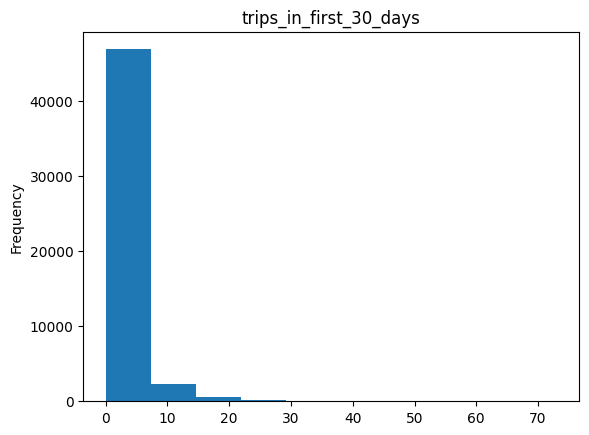

In [187]:
trips = trips[trips['trips_in_first_30_days'] != 125]

trips['trips_in_first_30_days'].plot(kind='hist', title='trips_in_first_30_days')
plt.show()

This looks more reasonable.  Let's fill the nas and look at the categorical columns.

In [188]:
median = trips['avg_rating_by_driver'].median()
median

np.float64(5.0)

In [189]:
median_by = trips['avg_rating_by_driver'].median()
median_of = trips['avg_rating_of_driver'].median()
trips['avg_rating_by_driver'] = trips['avg_rating_by_driver'].fillna(median_by)
trips['avg_rating_of_driver'] = trips['avg_rating_of_driver'].fillna(median_of)
trips['phone'] = trips['phone'].fillna('Unknown')
trips.isna().sum()

city                      0
trips_in_first_30_days    0
signup_date               0
avg_rating_of_driver      0
avg_surge                 0
last_trip_date            0
phone                     0
surge_pct                 0
ultimate_black_user       0
weekday_pct               0
avg_dist                  0
avg_rating_by_driver      0
dtype: int64

In [190]:
trips['phone'].value_counts()

phone
iPhone     34581
Android    15022
Unknown      396
Name: count, dtype: int64

In [191]:
trips['ultimate_black_user'].value_counts()

ultimate_black_user
False    31146
True     18853
Name: count, dtype: int64

All reasonable.  The final step before moving on to modelling is to define our target. The instructions said that the data is from several months in June 2014 but does not specify the final data data was collected.  If we need to define an inactive user as someone whose late ride date is more than 30 days before the last day data was collected, we need to know the range of the data.  To do this, we can plot the last_trip_date and see when the last recorded trip is.  Also, we should look at the average interval between trips, then define the end point of the data collection as the last trip + average interval.  Then users will be defined as active or inactive if they had a trip with the last 30 days before that end point.

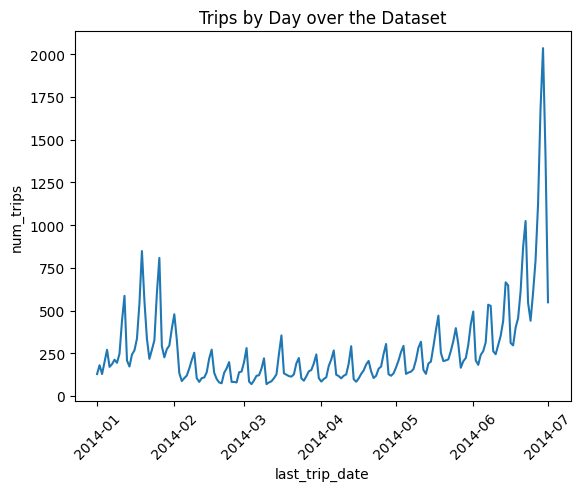

In [192]:
daily_trips = trips.groupby('last_trip_date').size().reset_index(name='num_trips')
sns.lineplot(data=daily_trips, x='last_trip_date', y='num_trips')
plt.xticks(rotation=45)
plt.title('Trips by Day over the Dataset')
plt.show()

In [193]:
sorted_trips = trips.sort_values('last_trip_date', ascending=False)

In [194]:
last_day = trips[trips['last_trip_date'] == pd.Timestamp('2014-07-01')]
last_day.shape

(548, 12)

This shows us that the last day was July 1, 2014 and there were 548 trips that day. This makes it very likely that the last day of data collection was 2014-07-01.  We will define inactive users as any whose last trip was before 2014-06-01.  

1 = Active  
0 = Inactive

In [195]:
trips['status'] = trips['last_trip_date'] > pd.Timestamp('2014-06-01')
status_dict = {True:1, False:0}
trips['status'] = trips['status'].map(status_dict)
trips.head()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,status
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0,1
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0,0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0,0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9,1
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9,0


In [196]:
trips['status'].value_counts()

status
0    31690
1    18309
Name: count, dtype: int64

According to this calculation, 18309 out of 49,999 users, or 36.6%, are inactive.  Now we can build a model to try to find out what features are associated with inactive users.

### Model Building

As this is a classification problem, we will use the following plan:
1. Train/test split
2. Standardize numeric columns
3. One Hot Encode categorical columns
4. Screen Classifiers
5. Hyperparameter Tune Top Classifier

For our metric, we will use the ROC-AUC as this does a good job generalizing for false positives and false negatives.  In this buisiness problem, there is not a clear difference in the importance of detecting inactive vs active users, since the goal of the project is understanding why users are inactive.  We will also use the confusion matrix to tell us where the mistakes are happening and give further insight into optimizations.

In [243]:
from catboost import CatBoostClassifier
import shap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV
from xgboost import XGBClassifier

In [ ]:
#Extact meaningful features from date_time columns into categorical columns
trips['start_month'] = trips['signup_date'].dt.month
trips['start_day'] = trips['signup_date'].dt.day
#make new df for modelling before we start changing columns too much. Remove the last trip date because that is essentially the target.
trips_model = trips.copy()
trips_model = trips_model.drop(columns=['signup_date', 'last_trip_date'])
trips_model.head()


,city,trips_in_first_30_days,avg_rating_of_driver,avg_surge,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,status,start_month,start_day
0,King's Landing,4,4.7,1.10,iPhone,15.4,True,46.2,3.67,5.0,1,1,25
1,Astapor,0,5.0,1.00,Android,0.0,False,50.0,8.26,5.0,0,1,29
2,Astapor,3,4.3,1.00,iPhone,0.0,False,100.0,0.77,5.0,0,1,6
3,King's Landing,9,4.6,1.14,iPhone,20.0,True,80.0,2.36,4.9,1,1,10
4,Winterfell,14,4.4,1.19,Android,11.8,False,82.4,3.13,4.9,0,1,27


In [198]:
X = trips_model.drop(columns='status')
y = trips_model['status']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=42)

In [200]:
num_cols = ['trips_in_first_30_days', 'avg_rating_of_driver', 'avg_surge', 'surge_pct', 'weekday_pct', 'avg_dist', 'avg_rating_by_driver']
cat_cols = ['city', 'phone', 'ultimate_black_user', 'start_month', 'start_day']

processor = ColumnTransformer([('num', StandardScaler(), num_cols), ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])

model_RF = Pipeline([('prep', processor), ('model', RandomForestClassifier())])

scores = cross_validate(model_RF, X_train, y_train, cv=5, scoring=['accuracy', 'roc_auc', 'precision', 'recall'])
print({k: v.mean() for k, v in scores.items() if 'test' in k})

{'test_accuracy': np.float64(0.7758872631906477), 'test_roc_auc': np.float64(0.8372769082233846), 'test_precision': np.float64(0.7168823988970888), 'test_recall': np.float64(0.6409471766848815)}


In [201]:
model_RF.fit(X_train, y_train)
y_pred_RF = model_RF.predict(X_test)
y_prob_RF = model_RF.predict_proba(X_test)[:,1]

In [202]:
roc_auc_score(y_test, y_prob_RF)

0.8304829141853334

In [204]:
confusion_matrix(y_test, y_pred_RF)

array([[6664, 1252],
       [1639, 2945]])

In [205]:
processor = ColumnTransformer([('num', StandardScaler(), num_cols), ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])

model_XG = Pipeline([('prep', processor), ('model', XGBClassifier())])
scores = cross_validate(model_XG, X_train, y_train, cv=5, scoring=['accuracy', 'roc_auc', 'precision', 'recall'])
print({k: v.mean() for k, v in scores.items() if 'test' in k})


{'test_accuracy': np.float64(0.7904210445837222), 'test_roc_auc': np.float64(0.8573292746669452), 'test_precision': np.float64(0.7375324668318677), 'test_recall': np.float64(0.6635336976320583)}


In [206]:
model_XG.fit(X_train, y_train)
y_pred_XG = model_XG.predict(X_test)
y_prob_XG = model_XG.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_prob_XG)

0.8517779287227936

In [207]:
confusion_matrix(y_test, y_pred_XG)

array([[6749, 1167],
       [1530, 3054]])

In [208]:
processor = ColumnTransformer([('num', StandardScaler(), num_cols), ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])

model_CB = Pipeline([('prep', processor), ('model', CatBoostClassifier(verbose=False))])

scores = cross_validate(model_CB, X_train, y_train, cv=5, scoring=['accuracy', 'roc_auc', 'precision', 'recall'])
print({k: v.mean() for k, v in scores.items() if 'test' in k})

{'test_accuracy': np.float64(0.7957545521625106), 'test_roc_auc': np.float64(0.8628071073772686), 'test_precision': np.float64(0.7471540712670119), 'test_recall': np.float64(0.6680510018214936)}


In [209]:
model_CB.fit(X_train, y_train)
y_pred_CB = model_CB.predict(X_test)
y_prob_CB = model_CB.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_prob_CB)

0.856985655777461

In [210]:
confusion_matrix(y_test, y_pred_CB)

array([[6804, 1112],
       [1543, 3041]])

All three models had very similar results accross all metrics with similar levels of false positives and false negatives. 

Random Forest AUC = 0.830
XGBoost AUC = 0.852
CatBoost AUC = 0.857

These results are all very promising and, in repsponse to the prompt, there is no reason to consider other alternatives, such as logistic regression or other classifiers.  The consistency of the results of these three model supports the validity of this approach. I find the balance between false negatives and false positives reassuring, as it shows us that the model is able to define both classes and is really learning the difference between them.

Next, I'll run hyperparameter tuning with the XGBoost model.  I am choosing this model because it's faster than CatBoost with very similar metics.

### Hyperparameter Tuning

In [217]:
param_grid = {
    'model__booster': ['gbtree', 'dart'],
    'model__learning_rate': np.arange(0.01, 1, 0.1),
    'model__reg_lambda': [0.5, 1, 2, 5],
    'model__gamma': [0, 0.1, 0.5, 1],
    'model__max_depth': [3, 5, 7, 9, 10]
}
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])
model = Pipeline([('prep', preprocessor), ('model', XGBClassifier())])

XGB_cv = RandomizedSearchCV(estimator=model, param_distributions=param_grid, cv=5, scoring='roc_auc')

XGB_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__booster': ['gbtree', 'dart'], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': array([0.01, ..., 0.81, 0.91]), 'model__max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validati

In [224]:
results_XGB = pd.DataFrame(XGB_cv.cv_results_)
top_10_XGB = results_XGB.sort_values(by='mean_test_score', ascending=False).head(10)
params_expanded = pd.json_normalize(top_10_XGB['params'])
top_10_XGB_full = pd.concat([top_10_XGB[["rank_test_score", "mean_test_score"]].reset_index(drop=True), params_expanded.reset_index(drop=True)], axis=1)
top_10_XGB_full['Mean AUC'] = top_10_XGB_full['mean_test_score']
top_10_XGB_full = top_10_XGB_full.drop('mean_test_score', axis=1)
top_10_XGB_full

,rank_test_score,model__reg_lambda,model__max_depth,model__learning_rate,model__gamma,model__booster,Mean AUC
0,1,2.0,3,0.41,0.0,gbtree,0.860066
1,2,2.0,3,0.21,1.0,gbtree,0.858835
2,3,1.0,3,0.71,0.5,dart,0.857655
3,4,0.5,5,0.61,1.0,dart,0.855700
4,5,0.5,3,0.91,0.5,dart,0.853753
5,6,2.0,9,0.01,0.0,dart,0.847180
6,7,0.5,7,0.41,0.1,dart,0.845088
7,8,2.0,10,0.51,0.5,dart,0.844090
8,9,5.0,9,0.91,0.5,gbtree,0.837258
9,10,2.0,9,0.51,0.0,gbtree,0.837046


In [230]:
preprocessor = ColumnTransformer([('num', StandardScaler(), num_cols), ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])
model = XGBClassifier(booster = 'gbtree', reg_lambda=2.0, gamma= 0, learning_rate=0.41, max_depth=3)
final_model_XG = Pipeline([('prep', preprocessor), ('model', model)])
final_model_XG = final_model_XG.fit(X_train, y_train)
y_pred_XGB = final_model_XG.predict(X_test)
y_prob_XGB = final_model_XG.predict_proba(X_test)[:,1]

In [231]:
roc_auc_score(y_test, y_prob_XGB)

0.856329345342501

In [234]:
confusion_matrix(y_test, y_pred_XGB)

array([[6789, 1127],
       [1540, 3044]])

### Feature Importance

We have built a model that can accurately predict whether a user will be active 6 months after sign up date.  This model could be passed to the client to help them find at risk users as it current stands.  However, an even more useful result of this project would be insight into how those predictions were made.  To do this, we will look at the feature importance as determined by the XGBoost model.

In [235]:
feature_names = X_test.columns
perm_XG = permutation_importance(final_model_XG, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2)

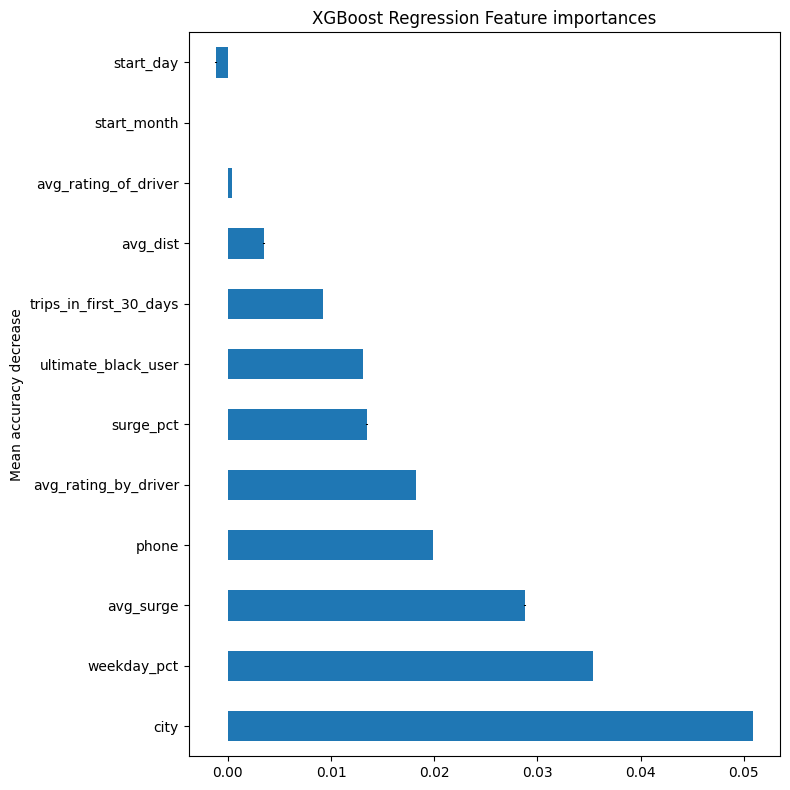

In [236]:
#Transform feature importance data into series for plotting
importances_mean = pd.Series(perm_XG.importances_mean, index=feature_names).sort_values(ascending=False)
importances_std = pd.Series(perm_XG.importances_std, index=feature_names).loc[importances_mean.index]

#Plot feature importances
fig, ax = plt.subplots(figsize=(8,8))
importances_mean.plot.barh(yerr=importances_std, ax=ax)
ax.set_title("XGBoost Regression Feature importances")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

From here we can see that the city, percent usage on weekdays, average surge multiplier and other features are important in determining a clients predicted status, but we don't know what about those catergories makes them informative.  To do this, we can look at Shap values.

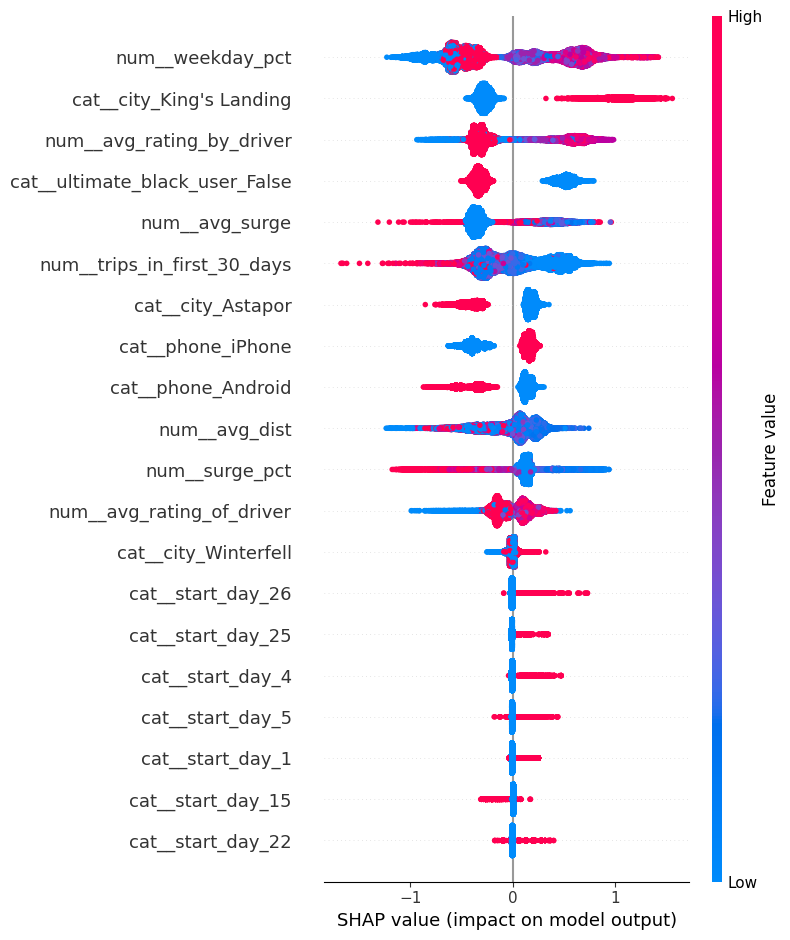

In [250]:
X_train_transformed = final_model_XG.named_steps['prep'].transform(X_train)

feature_names = final_model_XG.named_steps['prep'].get_feature_names_out()
X_train_transformed_df = pd.DataFrame(
    X_train_transformed.toarray() if hasattr(X_train_transformed, "toarray") else X_train_transformed,
    columns=feature_names
)
xgb_model = final_model_XG.named_steps['model']
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train_transformed)
shap.summary_plot(shap_values, X_train_transformed_df, feature_names=feature_names)

A positive SHAP value pushes a prediction towards class 1 (Active) and a negative SHAP value pushes a prediction towards class 0 (Inactive). Red indicates high values, and blue indicates low values, and each dot represents a prediction. So blue dots on the postive (right) side of the x-axis mean that low values in that catergory inform class 1 predictions, while red dots on the right side of the axis mean that high values inform class 1 predictions.  This can be used to gain useful recommendations for the client. Here are few examples:

1. People in King's Landing (who have a 1 in the King's Landing Hot Encoded column, so are red dots) tend to have a prediction of Active. 
    - King's Landing clients seem to be more stable.  Maybe Ultimate should advertise there to get more of these stable clients.
    - The opposite is seen for Astopor clients. These riders tend to be inactive after 6 months.
2. Ultimate Black User False was encoded here so that people who aren't black users become 1, which is high value and shown as red dots.  As these dots are clustered on the left side of the axis, they inform predictions of Inactive.  To get rid of our double negative, ultimate black users tend to be Active.
    - If Ultimate has demographic data on ultimate black vs non-black users, getting more clients with similar demographics as black users might increase their rider retention.
3. The users' phone type was very informative in this model.  iPhone users (True or 1 in the iPhone column) are on the right side, so more likely to be Active.  Android users (True or 1 in the Androd column) are more likely to be Inactive.
    - Ultimate could use this information in to either try to reach out to Android users to prevent them from leaving (maybe thier app doesn't work well on Android phones) or to try to get more client with iPhones since these clients are already more stable.
4. High surge_pct (the percent of trips with a surge multiplier) is associated with lower rider retention.  Maybe Ultimate could decrease it's surge pricing or offer rebates to clients who often travel during surge times to prevent these client from becoming inactive.